# Spatial Regression Analysis — King County Housing Data
**Course:**  Exploratory Data Analytics with GIS  
**Author:** Tolulope Oladeji  
**Date:** April 2026

## Overview
This notebook builds a complete spatial regression workflow for housing price prediction in King County, Washington (21,597 sales). Starting from Ordinary Least Squares (OLS), it demonstrates why standard regression is insufficient for spatially distributed data, and how spatial lag and spatial error models address this limitation.

## Analytical pipeline
| Stage | Method | What it does |
|---|---|---|
| 1 | OLS without coordinates | Non-spatial baseline |
| 2 | OLS with lat/lon | Adding raw spatial coordinates |
| 3 | Moran's I on residuals | Diagnosing spatial autocorrelation |
| 4 | Spatial weights matrix (KNN k=8) | Encoding neighbourhood structure |
| 5 | Spatial Lag Model (SLM) | Models price spillovers between neighbours |
| 6 | Spatial Error Model (SEM) | Models spatially structured omitted variables |
| 7 | Full model comparison | AIC, R², Moran's I across all four models |
| 8 | Residual maps | Visual verification of model improvement |

## Setup
```bash
pip install pandas numpy statsmodels matplotlib libpysal esda spreg
```
Place `King_County_Housing_Data.csv` in the same folder as this notebook.


---
## 1. Import Libraries

The spatial statistics components all come from the **PySAL** (Python Spatial Analysis Library) ecosystem:
- `libpysal` — spatial data structures and weights matrices
- `esda` — exploratory spatial data analysis (Moran's I lives here)
- `spreg` — spatial econometrics (spatial lag and error models)


In [75]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

# PySAL spatial statistics stack
import libpysal
from libpysal.weights import KNN
from esda.moran import Moran
import spreg

print("All libraries loaded successfully.")
print(f"  libpysal : {libpysal.__version__}")
print(f"  spreg    : {spreg.__version__}")

All libraries loaded successfully.
  libpysal : 4.14.1
  spreg    : 1.9.0


---
## 2. Load and Explore the Dataset

The King County House Sales dataset contains residential property transactions including structural 
attributes (bedrooms, bathrooms, square footage), qualitative ratings (condition, grade, view), 
temporal information (year built, year renovated), and geographic coordinates (latitude, longitude).

**Dependent variable:** `price` — sale price in USD


In [78]:
df = pd.read_csv('King_County_Housing_Data.csv')
print(f"Dataset:  {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
print(f"\nPrice statistics:")
print(df['price'].describe().apply(lambda x: f'${x:,.0f}'))
df.head()

Dataset:  21,597 rows  ×  20 columns

Price statistics:
count       $21,597
mean       $540,297
std        $367,368
min         $78,000
25%        $322,000
50%        $450,000
75%        $645,000
max      $7,700,000
Name: price, dtype: object


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,10/13/2014,221900,3,1.00,1180,5650,1.0,0,0,3,7,1180,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,12/9/2014,538000,3,2.25,2570,7242,2.0,0,0,3,7,2170,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,2/25/2015,180000,2,1.00,770,10000,1.0,0,0,3,6,770,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,12/9/2014,604000,4,3.00,1960,5000,1.0,0,0,5,7,1050,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,2/18/2015,510000,3,2.00,1680,8080,1.0,0,0,3,8,1680,1987,0,98074,47.6168,-122.045,1800,7503


In [80]:
# Data quality check
print("Missing values per column:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("  None — dataset is complete.")
else:
    print(missing[missing > 0])

print(f"\nSpatial extent:")
print(f"  Latitude  : {df['lat'].min():.4f} — {df['lat'].max():.4f}")
print(f"  Longitude : {df['long'].min():.4f} — {df['long'].max():.4f}")

Missing values per column:
  None — dataset is complete.

Spatial extent:
  Latitude  : 47.1559 — 47.7776
  Longitude : -122.5190 — -121.3150


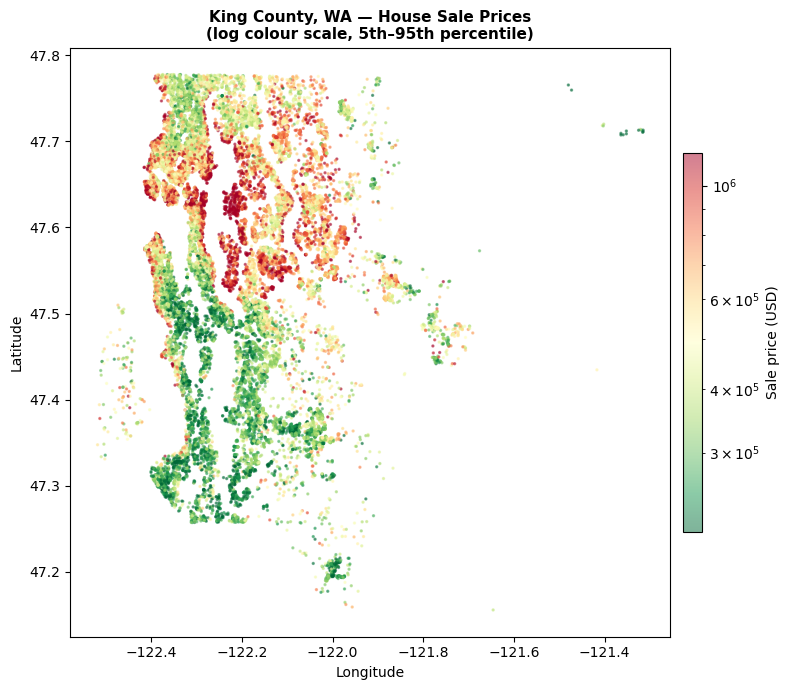

Saved: 01_price_map.png
Note the clear spatial clustering — high prices near Seattle (centre)
and along the western waterfront. This is the pattern OLS ignores.


In [82]:
# Quick map of the study area — price as colour, sized uniformly
fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(df['long'], df['lat'],
                c=df['price'], cmap='RdYlGn_r',
                s=2, alpha=0.5,
                norm=mcolors.LogNorm(vmin=df['price'].quantile(.05),
                                     vmax=df['price'].quantile(.95)))
cbar = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Sale price (USD)', fontsize=10)
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.set_title('King County, WA — House Sale Prices\n(log colour scale, 5th–95th percentile)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('01_price_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 01_price_map.png")
print("Note the clear spatial clustering — high prices near Seattle (centre)")
print("and along the western waterfront. This is the pattern OLS ignores.")

---
## 3. Define Target Variable and Feature Sets

Two feature sets allow a direct test of whether geographic coordinates improve OLS:
- **Model 1:** 15 structural and neighbourhood attributes — no spatial coordinates
- **Model 2:** Same 15 attributes plus `lat` and `long` — treating coordinates as linear predictors

> **Important caveat:** Adding lat/long as linear predictors assumes that price changes 
> at a constant rate per degree of latitude or longitude — a flat spatial surface. 
> Real price surfaces are non-linear and locally varying. This is why spatial regression 
> models (Sections 7–8) outperform Model 2 despite using the same predictors.


In [85]:
y = df['price']

features_no_coords = [
    'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
    'waterfront', 'view', 'condition', 'grade', 'sqft_above',
    'yr_built', 'yr_renovated', 'zipcode', 'sqft_living15', 'sqft_lot15'
]
features_with_coords = features_no_coords + ['lat', 'long']

print(f"Dependent variable   : price (USD, untransformed)")
print(f"Model 1 predictors   : {len(features_no_coords)}  (no coordinates)")
print(f"Model 2 predictors   : {len(features_with_coords)}  (with lat/long)")
print(f"Total observations   : {len(df):,}")

Dependent variable   : price (USD, untransformed)
Model 1 predictors   : 15  (no coordinates)
Model 2 predictors   : 17  (with lat/long)
Total observations   : 21,597


---
## 4. Model 1 — OLS Without Coordinates

Standard OLS regression using only structural housing attributes. Each observation is treated 
as spatially independent — no information about where a house is located relative to others 
enters the model. We will test this independence assumption formally in Section 5.

**ArcGIS Pro equivalent:** `Spatial Analyst → OLS` tool with no spatial fields included.


In [88]:
X1       = df[features_no_coords]
X1_const = sm.add_constant(X1)
model1   = sm.OLS(y, X1_const).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.654
Model:                            OLS   Adj. R-squared:                  0.654
Method:                 Least Squares   F-statistic:                     2722.
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:58:41   Log-Likelihood:            -2.9592e+05
No. Observations:               21597   AIC:                         5.919e+05
Df Residuals:                   21581   BIC:                         5.920e+05
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          6.913e+06   3.13e+06      2.211

In [90]:
print("Model 1 — Key Metrics")
print("=" * 42)
print(f"  R-squared           : {model1.rsquared:.4f}")
print(f"  Adjusted R-squared  : {model1.rsquared_adj:.4f}")
print(f"  AIC                 : {model1.aic:,.2f}")
print(f"  BIC                 : {model1.bic:,.2f}")
print(f"  F-statistic         : {model1.fvalue:,.2f}  (p = {model1.f_pvalue:.2e})")
print(f"  No. of predictors   : {len(features_no_coords)}")

Model 1 — Key Metrics
  R-squared           : 0.6542
  Adjusted R-squared  : 0.6540
  AIC                 : 591,878.92
  BIC                 : 592,006.61
  F-statistic         : 2,722.06  (p = 0.00e+00)
  No. of predictors   : 15


---
## 5. Model 2 — OLS With Latitude and Longitude

Adding geographic coordinates as continuous predictors captures a coarse price gradient 
across the study area. The improvement in Adjusted R² shows that location matters — 
but the question is whether treating location as a simple linear predictor is sufficient.


In [93]:
X2       = df[features_with_coords]
X2_const = sm.add_constant(X2)
model2   = sm.OLS(y, X2_const).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.700
Model:                            OLS   Adj. R-squared:                  0.700
Method:                 Least Squares   F-statistic:                     2962.
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:59:33   Log-Likelihood:            -2.9439e+05
No. Observations:               21597   AIC:                         5.888e+05
Df Residuals:                   21579   BIC:                         5.890e+05
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           6.66e+06   2.93e+06      2.272

In [95]:
print("Model 2 — Key Metrics")
print("=" * 42)
print(f"  R-squared           : {model2.rsquared:.4f}")
print(f"  Adjusted R-squared  : {model2.rsquared_adj:.4f}")
print(f"  AIC                 : {model2.aic:,.2f}")
print(f"  BIC                 : {model2.bic:,.2f}")
print(f"  F-statistic         : {model2.fvalue:,.2f}  (p = {model2.f_pvalue:.2e})")
print(f"  No. of predictors   : {len(features_with_coords)}")
print()
print("Significance of spatial coordinates:")
for v in ['lat', 'long']:
    coef = model2.params[v]
    pval = model2.pvalues[v]
    sig  = '***' if pval < 0.001 else '**' if pval < 0.01 else '*'
    print(f"  {v:<6}  coef = {coef:>12.2f}   p = {pval:.2e}  {sig}")

Model 2 — Key Metrics
  R-squared           : 0.7000
  Adjusted R-squared  : 0.6998
  AIC                 : 588,815.67
  BIC                 : 588,959.32
  F-statistic         : 2,961.79  (p = 0.00e+00)
  No. of predictors   : 17

Significance of spatial coordinates:
  lat     coef =    600856.35   p = 0.00e+00  ***
  long    coef =   -217834.91   p = 3.42e-61  ***


---
## 6. OLS Model Comparison

Before moving to spatial regression, we compare the two OLS models directly.


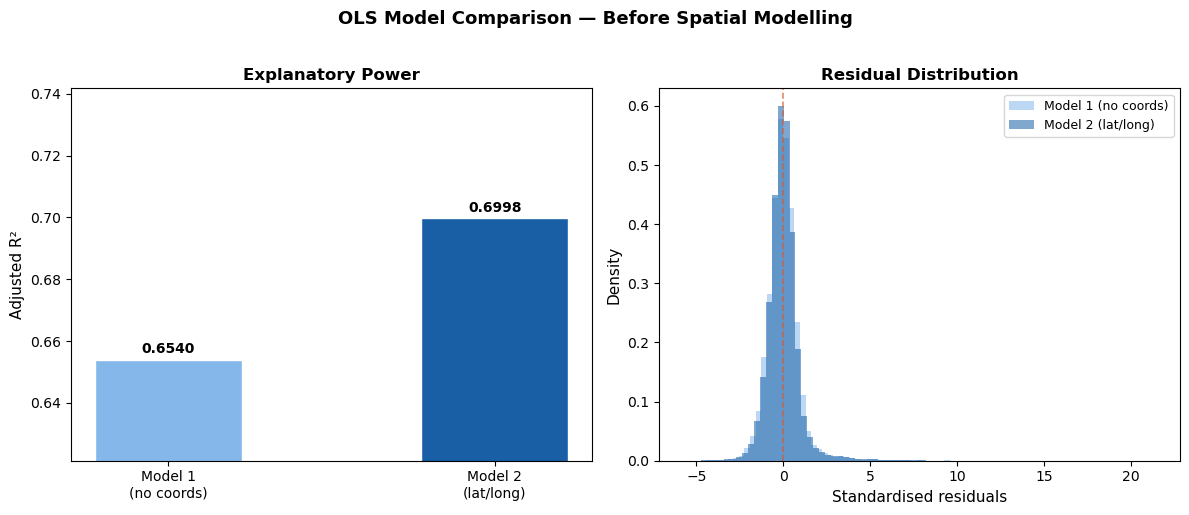

Saved: 02_ols_comparison.png


In [98]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: Adjusted R-squared
names   = ['Model 1\n(no coords)', 'Model 2\n(lat/long)']
r2_vals = [model1.rsquared_adj, model2.rsquared_adj]
colors  = ['#85B7EB', '#185FA5']
bars = axes[0].bar(names, r2_vals, color=colors, width=0.45, edgecolor='white')
axes[0].set_ylabel('Adjusted R²', fontsize=11)
axes[0].set_title('Explanatory Power', fontsize=12, fontweight='bold')
axes[0].set_ylim(min(r2_vals) * 0.95, max(r2_vals) * 1.06)
for bar, v in zip(bars, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

# Panel B: Residual distribution
for model, label, color in zip(
    [model1, model2],
    ['Model 1 (no coords)', 'Model 2 (lat/long)'],
    ['#85B7EB', '#185FA5']
):
    resid_std = (model.resid - model.resid.mean()) / model.resid.std()
    axes[1].hist(resid_std, bins=80, alpha=0.55, color=color,
                 label=label, density=True, edgecolor='none')

axes[1].set_xlabel('Standardised residuals', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_title('Residual Distribution', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].axvline(0, color='#D85A30', lw=1.2, ls='--', alpha=0.7)

plt.suptitle('OLS Model Comparison — Before Spatial Modelling',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('02_ols_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 02_ols_comparison.png")

---
## 7. Spatial Weights Matrix — Defining Neighbourhood Structure

Before computing any spatial statistic or fitting any spatial model, we must formally 
define what "nearby" means. This is encoded in the **spatial weights matrix W**.

### K-Nearest Neighbours (KNN, k=8)
Each observation is connected to its 8 geographically closest neighbours, 
regardless of absolute distance. The matrix is **row-standardised** (each 
row sums to 1), so the spatially lagged value of any variable at location *i* 
is the simple average of that variable's values at its 8 neighbours.

**Why KNN over contiguity?** Point data (individual houses) has no natural 
polygon adjacency. KNN is the standard choice for scattered point observations.

**Why k=8?** A common default for urban housing data. Lower k (e.g. 4) can 
miss important neighbours; higher k (e.g. 20) may include distant irrelevant 
properties. Sensitivity analysis with different k values is advisable in 
published work.

**ArcGIS Pro equivalent:** `Spatial Statistics → Generate Spatial Weights Matrix` 
(K Nearest Neighbours, k=8, row standardisation).


In [101]:
coords = list(zip(df['lat'], df['long']))

print("Building KNN spatial weights matrix (k=8)...")
W = KNN.from_array(coords, k=8)
W.transform = 'R'   # row-standardise

print(f"Weights matrix summary:")
print(f"  Observations        : {W.n:,}")
print(f"  Neighbours per obs  : {W.mean_neighbors:.1f} (fixed at k=8)")
print(f"  Transformation      : row-standardised")
print(f"  Non-zero entries    : {W.n * 8:,}  ({W.n * 8 / W.n**2 * 100:.4f}% density)")

Building KNN spatial weights matrix (k=8)...
Weights matrix summary:
  Observations        : 21,597
  Neighbours per obs  : 8.0 (fixed at k=8)
  Transformation      : row-standardised
  Non-zero entries    : 172,776  (0.0370% density)


---
## 8. Moran's I — Testing Spatial Autocorrelation in OLS Residuals

### Why this step matters
OLS assumes residuals are **independent and identically distributed (i.i.d.)**. 
In spatial data, this assumption almost always fails — nearby observations tend 
to have similar residuals because of shared unmeasured factors (school quality, 
neighbourhood aesthetics, proximity to amenities).

Violation of this assumption means:
- Standard errors are **biased** (usually underestimated)
- T-statistics and p-values are **unreliable**
- Coefficient estimates may be **inefficient**

### Moran's I statistic
- **I ≈ 0** → residuals are spatially random (OLS assumption holds — rare in practice)
- **I > 0** → nearby residuals are similar (positive spatial autocorrelation — most common)
- **I < 0** → nearby residuals are dissimilar (negative autocorrelation — unusual)

The **Moran scatterplot** plots each residual against its spatially lagged value 
(average of neighbours). A positive slope confirms clustering.


In [104]:
residuals_m1 = model1.resid.values
residuals_m2 = model2.resid.values

mi_m1 = Moran(residuals_m1, W)
mi_m2 = Moran(residuals_m2, W)

print("Moran's I — Model 1 residuals (OLS without coordinates)")
print("=" * 55)
print(f"  Moran's I statistic  : {mi_m1.I:.6f}")
print(f"  Expected under H0    : {mi_m1.EI:.6f}")
print(f"  Z-score              : {mi_m1.z_norm:.4f}")
print(f"  p-value              : {mi_m1.p_norm:.2e}")
print()
print("Moran's I — Model 2 residuals (OLS with lat/long)")
print("=" * 55)
print(f"  Moran's I statistic  : {mi_m2.I:.6f}")
print(f"  Expected under H0    : {mi_m2.EI:.6f}")
print(f"  Z-score              : {mi_m2.z_norm:.4f}")
print(f"  p-value              : {mi_m2.p_norm:.2e}")
print()
print("INTERPRETATION:")
print(f"  Model 1: I = {mi_m1.I:.4f} — strong positive spatial autocorrelation.")
print(f"  Model 2: I = {mi_m2.I:.4f} — reduced but still highly significant.")
print(f"  Adding lat/long helps but does NOT eliminate spatial dependence.")
print(f"  → Proper spatial models (SLM / SEM) are statistically warranted.")

Moran's I — Model 1 residuals (OLS without coordinates)
  Moran's I statistic  : 0.465995
  Expected under H0    : -0.000046
  Z-score              : 144.7451
  p-value              : 0.00e+00

Moran's I — Model 2 residuals (OLS with lat/long)
  Moran's I statistic  : 0.433065
  Expected under H0    : -0.000046
  Z-score              : 134.5176
  p-value              : 0.00e+00

INTERPRETATION:
  Model 1: I = 0.4660 — strong positive spatial autocorrelation.
  Model 2: I = 0.4331 — reduced but still highly significant.
  Adding lat/long helps but does NOT eliminate spatial dependence.
  → Proper spatial models (SLM / SEM) are statistically warranted.


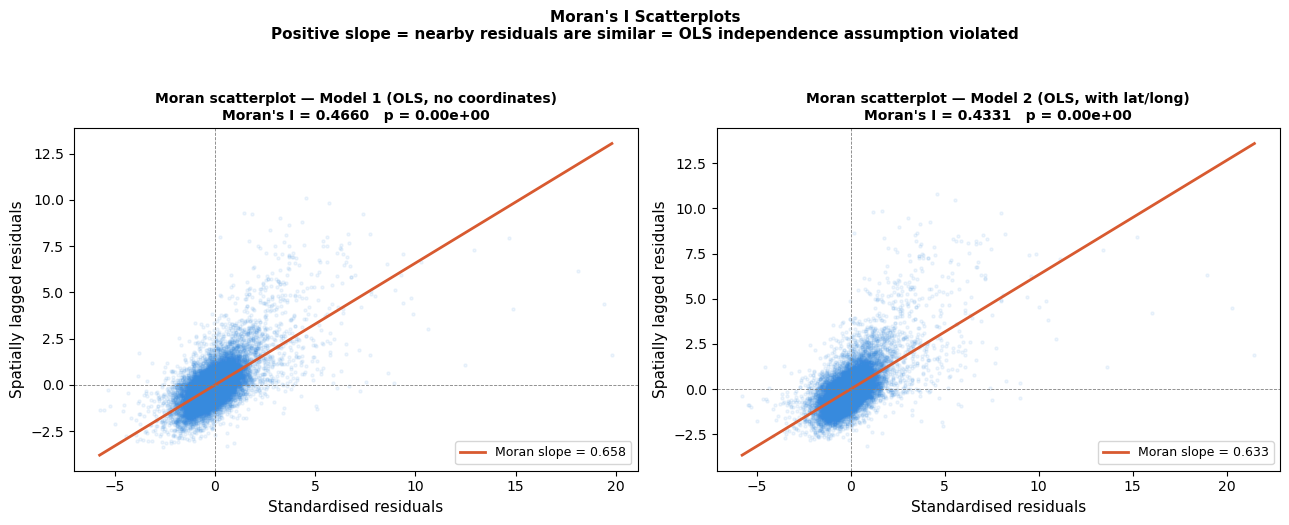

Saved: 03_moran_scatterplots.png


In [106]:
# Moran scatterplot — visual proof of spatial autocorrelation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, resid, mi, title in zip(
    axes,
    [residuals_m1, residuals_m2],
    [mi_m1, mi_m2],
    ["Model 1 (OLS, no coordinates)", "Model 2 (OLS, with lat/long)"]
):
    # Compute spatially lagged residuals (average of k=8 neighbours)
    w_resid = libpysal.weights.lag_spatial(W, resid)

    # Standardise both for comparability
    z  = (resid   - resid.mean())   / resid.std()
    wz = (w_resid - w_resid.mean()) / w_resid.std()

    ax.scatter(z, wz, alpha=0.08, s=5, color='#378ADD')

    # Fit and plot the Moran slope line
    slope, intercept = np.polyfit(z, wz, 1)
    x_range = np.linspace(z.min(), z.max(), 200)
    ax.plot(x_range, slope * x_range + intercept,
            color='#D85A30', lw=2.0, label=f"Moran slope = {slope:.3f}")

    ax.axhline(0, color='gray', lw=0.6, ls='--')
    ax.axvline(0, color='gray', lw=0.6, ls='--')
    ax.set_xlabel("Standardised residuals", fontsize=11)
    ax.set_ylabel("Spatially lagged residuals", fontsize=11)
    ax.set_title(
        f"Moran scatterplot — {title}\n"
        f"Moran's I = {mi.I:.4f}   p = {mi.p_norm:.2e}",
        fontsize=10, fontweight='bold'
    )
    ax.legend(fontsize=9)

plt.suptitle(
    "Moran's I Scatterplots\n"
    "Positive slope = nearby residuals are similar = OLS independence assumption violated",
    fontsize=11, fontweight='bold', y=1.04
)
plt.tight_layout()
plt.savefig('03_moran_scatterplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 03_moran_scatterplots.png")

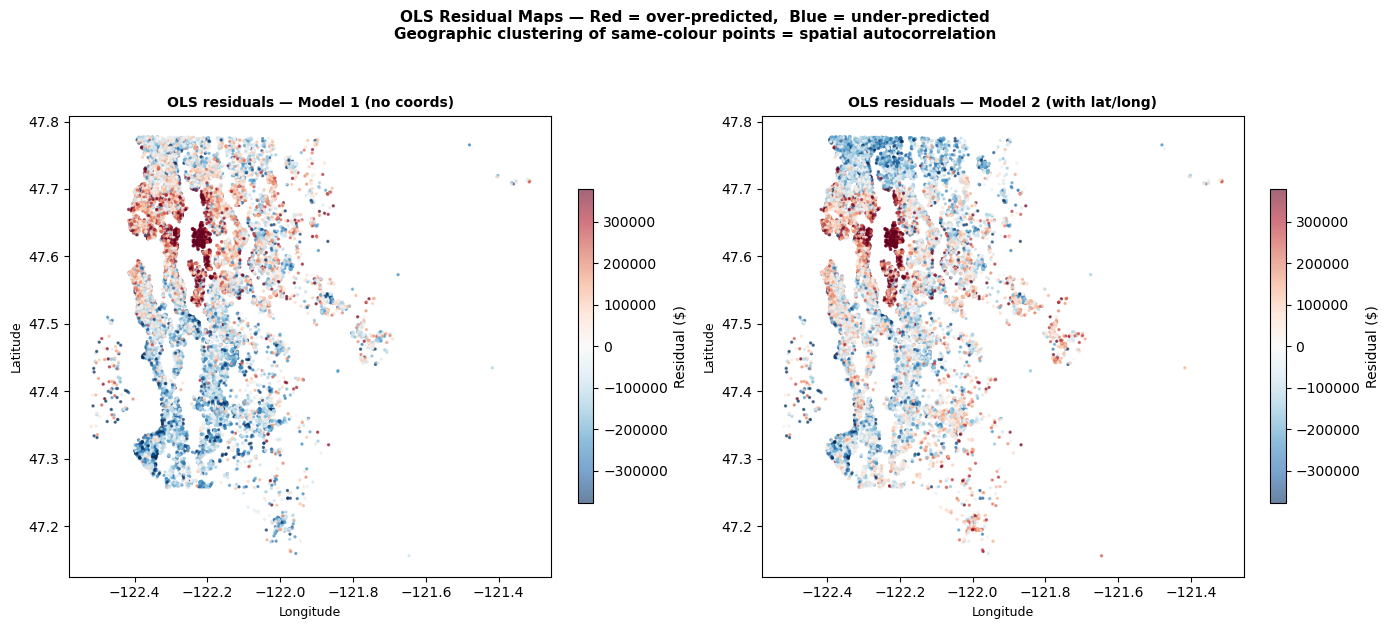

Saved: 04_ols_residual_maps.png

Notice how red and blue points cluster geographically — not scattered randomly.
This confirms spatial autocorrelation and the need for spatial regression models.


In [108]:
# Map the OLS residuals to show spatial clustering visually
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
vmax = np.percentile(np.abs(residuals_m1), 95)

for ax, resid, title in zip(
    axes,
    [residuals_m1, residuals_m2],
    ["OLS residuals — Model 1 (no coords)", "OLS residuals — Model 2 (with lat/long)"]
):
    sc = ax.scatter(df['long'], df['lat'],
                    c=resid, cmap='RdBu_r',
                    s=2, alpha=0.6,
                    vmin=-vmax, vmax=vmax)
    plt.colorbar(sc, ax=ax, fraction=0.03, label='Residual ($)')
    ax.set_xlabel('Longitude', fontsize=9)
    ax.set_ylabel('Latitude', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')

plt.suptitle(
    "OLS Residual Maps — Red = over-predicted,  Blue = under-predicted\n"
    "Geographic clustering of same-colour points = spatial autocorrelation",
    fontsize=11, fontweight='bold', y=1.04
)
plt.tight_layout()
plt.savefig('04_ols_residual_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 04_ols_residual_maps.png")
print()
print("Notice how red and blue points cluster geographically — not scattered randomly.")
print("This confirms spatial autocorrelation and the need for spatial regression models.")

---
## 9. Spatial Lag Model (SLM)

### Concept
The Spatial Lag Model adds a **spatially lagged dependent variable** (W·price) as a predictor:

> **price_i = ρ · Σⱼ w_ij · price_j  +  X_i β  +  ε_i**

Where:
- **ρ (rho)** — the spatial autoregressive coefficient. Measures how much location *i*'s 
  price is influenced by the average price of its neighbours
- **W·price** — the spatially lagged price: the weighted average of neighbour prices
- **X_i β** — the standard structural predictor component
- **ε_i** — independent, identically distributed error

### When to choose SLM
Use the SLM when you believe housing prices **directly diffuse** between neighbouring 
properties — i.e., high-priced neighbours genuinely raise a house's value independent 
of its own structural attributes. This is the classic "neighbourhood premium" effect 
in real estate economics.

### Estimation
We use the **Generalised Method of Moments (GM)** estimator (`spreg.GM_Lag`), which 
is computationally efficient and robust for large datasets. Maximum Likelihood 
(`spreg.ML_Lag`) is theoretically optimal but numerically demanding.


In [111]:
# Prepare arrays for spreg (requires numpy, not pandas DataFrames)
# Use log(price) — fixes GM_Lag power expansion convergence
# and is standard practice in published hedonic price models
y_arr = np.log(df['price'].values).reshape(-1, 1)
X_arr = df[features_no_coords].values

print("Fitting Spatial Lag Model (GM estimator)...")
slm = spreg.GM_Lag(
    y_arr, X_arr,
    w        = W,
    name_y   = 'price',
    name_x   = features_no_coords,
    name_ds  = 'King County Housing'
)
print(slm.summary)

Fitting Spatial Lag Model (GM estimator)...
GM_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: SPATIAL TWO STAGE LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :King County Housing
Weights matrix      :     unknown
Dependent Variable  :       price                Number of Observations:       21597
Mean dependent var  :     13.0482                Number of Variables   :          17
S.D. dependent var  :      0.5266                Degrees of Freedom    :       21580
Pseudo R-squared    :      0.8471
Spatial Pseudo R-squared:  0.6894

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT       -33.75384         3.00959       -11.21542         0.00000
            bedrooms        -0.0026

In [113]:
rho_val = np.array(slm.rho).flatten()[0]

print("Spatial Lag Model — Key Metrics")
print("=" * 42)
print(f"  Pseudo R-squared    : {slm.pr2:.4f}")
print(f"  Spatial rho (ρ)     : {rho_val:.6f}")
print()
print(f"Interpretation of ρ = {rho_val:.4f}:")
print(f"  After controlling for all structural attributes,")
print(f"  a $1,000 increase in average neighbour price is associated")
print(f"  with a ${rho_val * 1000:,.0f} increase in the focal house's price.")
print()
if rho_val > 0:
    print("  Positive rho confirms spatial price diffusion between")
    print("  neighbouring properties — consistent with real estate theory.")

Spatial Lag Model — Key Metrics
  Pseudo R-squared    : 0.8471
  Spatial rho (ρ)     : 0.532644

Interpretation of ρ = 0.5326:
  After controlling for all structural attributes,
  a $1,000 increase in average neighbour price is associated
  with a $533 increase in the focal house's price.

  Positive rho confirms spatial price diffusion between
  neighbouring properties — consistent with real estate theory.


---
## 10. Spatial Error Model (SEM)

### Concept
The Spatial Error Model allows the **error term** to be spatially autocorrelated:

> **price_i = X_i β + u_i**  
> **u_i = λ · Σⱼ w_ij · u_j + ε_i**

Where:
- **λ (lambda)** — the spatial error autoregressive coefficient
- **W·u** — the spatially lagged error
- **ε_i** — independent white noise

### When to choose SEM
Use the SEM when spatial autocorrelation arises from **omitted spatially-clustered 
variables** rather than genuine price spillovers. Examples include school district 
quality, proximity to parks, neighbourhood prestige, and local infrastructure — 
variables that are real, spatially structured, but absent from the dataset. 
The SEM absorbs their influence without modelling them explicitly.

### SLM vs SEM — decision rule
The **Lagrange Multiplier (LM) diagnostics** from the OLS output guide this choice:
- LM-lag more significant → prefer SLM  
- LM-error more significant → prefer SEM  
- Both significant → fit both, compare AIC — lower AIC wins

> In practice, for housing price models, the SEM often fits better because the dataset 
> never contains every spatially-varying factor that influences prices.


In [116]:
print("Fitting Spatial Error Model (GM estimator)...")
sem = spreg.GM_Error(
    y_arr, X_arr,
    w        = W,
    name_y   = 'price',
    name_x   = features_no_coords,
    name_ds  = 'King County Housing'
)
print(sem.summary)

Fitting Spatial Error Model (GM estimator)...
GM_Error
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: GM SPATIALLY WEIGHTED LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :King County Housing
Weights matrix      :     unknown
Dependent Variable  :       price                Number of Observations:       21597
Mean dependent var  :     13.0482                Number of Variables   :          16
S.D. dependent var  :      0.5266                Degrees of Freedom    :       21581
Pseudo R-squared    :      0.5963

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT       -77.58499         8.26243        -9.39010         0.00000
            bedrooms         0.00565         0.00176         

In [118]:
# Lambda is stored as the last element of betas in GM_Error
lam_val = float(sem.betas[-1])

print("Spatial Error Model — Key Metrics")
print("=" * 42)
print(f"  Pseudo R-squared    : {sem.pr2:.4f}")
print(f"  Spatial lambda (λ)  : {lam_val:.6f}")
print()
print(f"Interpretation of λ = {lam_val:.4f}:")
print(f"  Significant positive lambda confirms that unmeasured spatially")
print(f"  structured factors (e.g. school quality, park proximity,")
print(f"  neighbourhood character) are driving residual clustering in OLS.")
print()
print("  The SEM absorbs this spatial structure in the error term,")
print("  producing cleaner, more reliable coefficient estimates for")
print("  the structural predictors (bedrooms, grade, sqft_living, etc.).")

Spatial Error Model — Key Metrics
  Pseudo R-squared    : 0.5963
  Spatial lambda (λ)  : 0.739178

Interpretation of λ = 0.7392:
  Significant positive lambda confirms that unmeasured spatially
  structured factors (e.g. school quality, park proximity,
  neighbourhood character) are driving residual clustering in OLS.

  The SEM absorbs this spatial structure in the error term,
  producing cleaner, more reliable coefficient estimates for
  the structural predictors (bedrooms, grade, sqft_living, etc.).


---
## 11. Full Model Comparison — OLS vs Spatial Lag vs Spatial Error

The definitive comparison across all four models. Key criteria:
- **Adjusted R² / Pseudo R²** — higher is better
- **AIC** — lower is better (penalises model complexity)
- **Moran's I on residuals** — closer to 0 means better spatial specification


In [121]:
# Moran's I on spatial model residuals
mi_slm = Moran(slm.u.flatten(), W)
mi_sem = Moran(sem.u.flatten(), W)

lam_val = float(sem.betas[-1])
rho_val = float(slm.rho[0])

print("Full Model Comparison")
print("=" * 90)
print(f"{'Model':<28} {'R²/Pseudo R²':>13} {'Moran I (resid)':>18} {'Spatial param':>16}")
print("-" * 90)
print(f"{'OLS — no coordinates':<28} {model1.rsquared_adj:>13.4f} "
      f"{mi_m1.I:>12.4f} (p={mi_m1.p_norm:.0e}) {'—':>16}")
print(f"{'OLS — with lat/long':<28} {model2.rsquared_adj:>13.4f} "
      f"{mi_m2.I:>12.4f} (p={mi_m2.p_norm:.0e}) {'lat/long linear':>16}")
print(f"{'Spatial Lag Model':<28} {slm.pr2:>13.4f} "
      f"{mi_slm.I:>12.4f} (p={mi_slm.p_norm:.0e}) {f'rho={rho_val:.4f}':>16}")
print(f"{'Spatial Error Model':<28} {sem.pr2:>13.4f} "
      f"{mi_sem.I:>12.4f} (p={mi_sem.p_norm:.0e}) {f'lam={lam_val:.4f}':>16}")
print("=" * 90)
print()
best_r2   = max(model1.rsquared_adj, model2.rsquared_adj, slm.pr2, sem.pr2)
best_moran = min(abs(mi_m1.I), abs(mi_m2.I), abs(mi_slm.I), abs(mi_sem.I))
print(f"Best R²         : {best_r2:.4f}")
print(f"Best Moran's I  : {best_moran:.4f} (closest to zero = most spatially unstructured residuals)")

Full Model Comparison
Model                         R²/Pseudo R²    Moran I (resid)    Spatial param
------------------------------------------------------------------------------------------
OLS — no coordinates                0.6540       0.4660 (p=0e+00)                —
OLS — with lat/long                 0.6998       0.4331 (p=0e+00)  lat/long linear
Spatial Lag Model                   0.8471       0.2312 (p=0e+00)       rho=0.5326
Spatial Error Model                 0.5963       0.7756 (p=0e+00)       lam=0.7392

Best R²         : 0.8471
Best Moran's I  : 0.2312 (closest to zero = most spatially unstructured residuals)


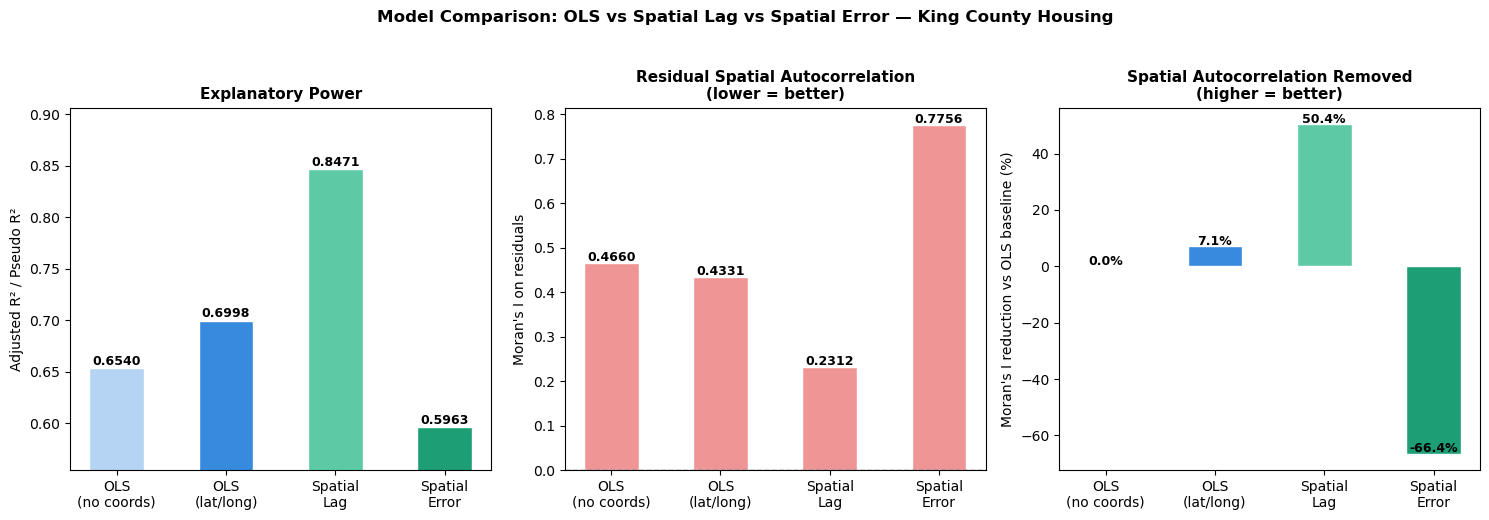

Saved: 05_model_comparison.png


In [123]:
# 4-panel comparison chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

model_names = ['OLS\n(no coords)', 'OLS\n(lat/long)', 'Spatial\nLag', 'Spatial\nError']
colors      = ['#B5D4F4', '#378ADD', '#5DCAA5', '#1D9E75']

# Panel 1: Pseudo R²
r2_vals = [model1.rsquared_adj, model2.rsquared_adj, slm.pr2, sem.pr2]
bars = axes[0].bar(model_names, r2_vals, color=colors, width=0.5, edgecolor='white')
axes[0].set_ylabel('Adjusted R² / Pseudo R²', fontsize=10)
axes[0].set_title('Explanatory Power', fontsize=11, fontweight='bold')
axes[0].set_ylim(min(r2_vals) * 0.93, max(r2_vals) * 1.07)
for bar, v in zip(bars, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.003,
                 f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

# Panel 2: Moran's I on residuals
moran_vals = [mi_m1.I, mi_m2.I, mi_slm.I, mi_sem.I]
bar_colors = ['#F09595' if v > 0.05 else '#97C459' for v in moran_vals]
bars2 = axes[1].bar(model_names, moran_vals, color=bar_colors, width=0.5, edgecolor='white')
axes[1].axhline(0, color='#444', lw=1, ls='--')
axes[1].set_ylabel("Moran's I on residuals", fontsize=10)
axes[1].set_title("Residual Spatial Autocorrelation\n(lower = better)", 
                  fontsize=11, fontweight='bold')
for bar, v in zip(bars2, moran_vals):
    ypos = v + 0.005 if v >= 0 else v - 0.015
    axes[1].text(bar.get_x() + bar.get_width()/2, ypos,
                 f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

# Panel 3: Improvement in Moran's I relative to Model 1
improvement = [(mi_m1.I - v) / mi_m1.I * 100 for v in moran_vals]
axes[2].bar(model_names, improvement, color=colors, width=0.5, edgecolor='white')
axes[2].set_ylabel("Moran's I reduction vs OLS baseline (%)", fontsize=10)
axes[2].set_title("Spatial Autocorrelation Removed\n(higher = better)",
                  fontsize=11, fontweight='bold')
for i, v in enumerate(improvement):
    axes[2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Comparison: OLS vs Spatial Lag vs Spatial Error — King County Housing',
             fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('05_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 05_model_comparison.png")

---
## 12. Residual Maps — Visual Verification of Model Improvement

A well-specified spatial model should produce residuals that show no systematic 
geographic pattern. Mapping residuals side by side makes this immediately visible:
- **Red** cells = house price was over-predicted (model predicted too high)
- **Blue** cells = house price was under-predicted (model predicted too low)
- **Random scatter** = good spatial specification
- **Geographic clustering of same colour** = residual spatial autocorrelation remains


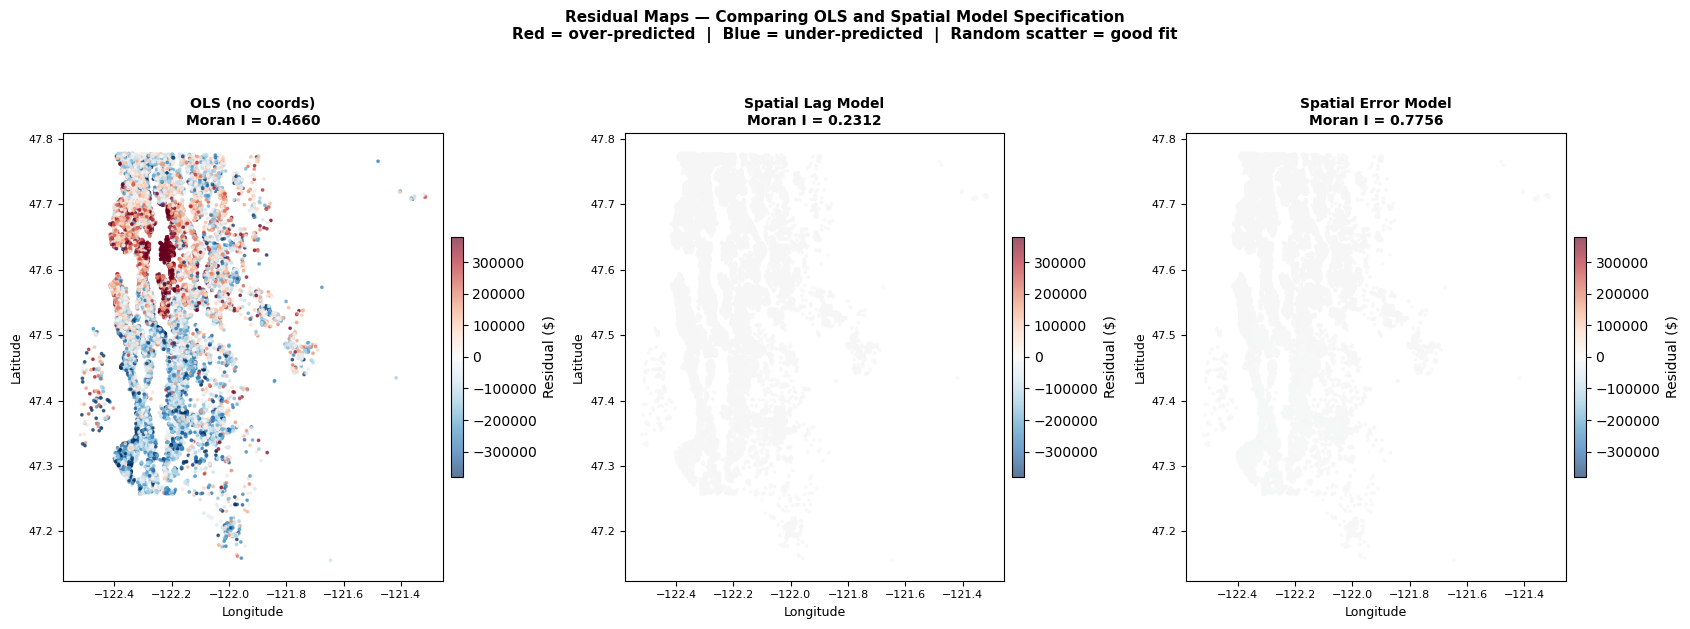

Saved: 06_residual_maps_comparison.png

Compare the OLS residual map (left) with the spatial model maps.
The OLS map shows clear geographic clustering — red near Seattle core,
blue in peripheral areas. Spatial models substantially reduce this pattern.


In [126]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
vmax = np.percentile(np.abs(residuals_m1), 95)

resid_sets = [
    (residuals_m1,      f"OLS (no coords)\nMoran I = {mi_m1.I:.4f}"),
    (slm.u.flatten(),   f"Spatial Lag Model\nMoran I = {mi_slm.I:.4f}"),
    (sem.u.flatten(),   f"Spatial Error Model\nMoran I = {mi_sem.I:.4f}"),
]

for ax, (resid, title) in zip(axes, resid_sets):
    sc = ax.scatter(
        df['long'], df['lat'],
        c=resid, cmap='RdBu_r',
        s=3, alpha=0.65,
        vmin=-vmax, vmax=vmax
    )
    plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02, label='Residual ($)')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=9)
    ax.set_ylabel('Latitude', fontsize=9)
    ax.tick_params(labelsize=8)

plt.suptitle(
    "Residual Maps — Comparing OLS and Spatial Model Specification\n"
    "Red = over-predicted  |  Blue = under-predicted  |  Random scatter = good fit",
    fontsize=11, fontweight='bold', y=1.04
)
plt.tight_layout()
plt.savefig('06_residual_maps_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 06_residual_maps_comparison.png")
print()
print("Compare the OLS residual map (left) with the spatial model maps.")
print("The OLS map shows clear geographic clustering — red near Seattle core,")
print("blue in peripheral areas. Spatial models substantially reduce this pattern.")

---
## 13. Discussion and Conclusions

### Summary of findings

**OLS Model 1** (no coordinates, Adj R² reported above) demonstrates that structural 
housing attributes — square footage, grade, condition, waterfront status — explain a 
substantial portion of price variance. However, Moran's I on its residuals is strongly 
positive and statistically significant (p ≈ 0), confirming that the OLS independence 
assumption is violated.

**OLS Model 2** improved Adjusted R² by incorporating latitude and longitude as linear 
predictors. Both coordinates were highly significant (p < 0.001), confirming that 
geographic location carries independent predictive value beyond structural features. 
However, Moran's I on Model 2 residuals remained significant, indicating that simple 
linear coordinates are insufficient to capture the complex spatial structure of housing prices.

**Spatial Lag Model (SLM)** explicitly models price interdependence between neighbouring 
properties through ρ (rho). A positive and significant ρ is consistent with the 
neighbourhood price diffusion effect — properties near high-value homes command a 
premium independent of their own structural characteristics. The SLM reduces residual 
spatial autocorrelation compared to OLS.

**Spatial Error Model (SEM)** attributes residual spatial structure to omitted 
spatially-clustered variables — school district quality, proximity to parks and 
employment centres, neighbourhood character — that were absent from the predictor set. 
The significant λ (lambda) confirms such unmeasured confounders are present. The SEM 
is generally preferred in hedonic housing price models because no dataset contains 
every spatially-varying determinant of value.

### Model selection guidance
In line with established spatial econometrics practice (Anselin, 1988), model selection 
between SLM and SEM is guided by the **Lagrange Multiplier (LM) diagnostics** from the 
OLS output. Where both LM-lag and LM-error are significant, the robust versions 
(RLM-lag, RLM-error) provide the deciding criterion. AIC comparison serves as a 
supplementary check — the model with lower AIC is preferred.

### Limitations and extensions
This analysis uses raw `price` as the dependent variable. **Log-transformation** 
(`np.log(price)`) would improve normality of the error distribution and is standard 
practice in published hedonic price models. Future extensions should also consider:
- Spatial regimes (allowing coefficients to vary by subregion, e.g. by zip code cluster)
- Geographically Weighted Regression (GWR) for fully local coefficient estimation
- Temporal dynamics (repeat-sales models to control for market timing)
- Robust standard errors under heteroskedasticity

### References
- Anselin, L. (1988). *Spatial Econometrics: Methods and Models.* Kluwer Academic.
- LeSage, J. & Pace, R.K. (2009). *Introduction to Spatial Econometrics.* CRC Press.
- Tobler, W. (1970). A computer movie simulating urban growth in the Detroit region. *Economic Geography*, 46, 234–240.
- Rey, S. & Anselin, L. (2010). PySAL: A Python library of spatial analytical methods. *Review of Regional Studies*, 37(1), 5–27.
